## **Tarea 1 : Clustering no supervisado para segmentar perfiles de postulación y matrícula**
#### Modelos de Machine Learning No-Supervisados

**Integrantes**
- Catalina Cornejo
- Hellen Quiñones
- Gustavo Sanchez


---

### 🌟🌟**Objetivo general**🌟🌟

Aplicar métodos de aprendizaje no supervisado para identificar perfiles latentes de estudiantes a partir de variables de postulación, matrícula y contexto educativo. Se espera que comparen distintos algoritmos de clustering, evalúen la calidad de las particiones obtenidas y discutan su utilidad sustantiva.

---


### 🌟🌟**Detalles de la data**🌟🌟
#### Dataset matrícula
- `MRUNANIO` (ID individuo-proceso)
- `MRUN` (RUT enmascarado)
- `ANYO_PROCESO` (Año del proceso de postulación)
- `coherence_5_0.05_` Distancia o similud entre las carreras postuladas por MRUNANIO.
- `GenericCareerID` (puede ser nombre o ID, en el dataset matricula corresponde a la carrera matriculada)
- `CAT_PERIODO_1` (Retención al primer año: 1 si retuvo, 0 si desertó)
- `PUNTAJE_PONDERADO`, (puedes incluir más puntajes pero estan altamente correlacionados, OJO hay que corregir el formato ej: 56490).
- `COD_SEXO` (Hombre 1 o Mujer 2)
- `PREFERENCIA` (Orden de preferencia matriculada: 1 se matricula en su primera preferencia, 5 en la quinta, etc.)
- `LUGAR` (Puesto en que entró a la carrera: 1 primer matriculado, 20 matriculado numero 20, etc.)
- `RBD` (Código/ID colegio)
- `DEPENDENCIA` (1 Corporación Municipal, 2 Municipal, 3 Particular Subvencionado, 4 Particular Pagado, 5 Corporación de Administración Delegada, otros)
- `NOMBRE_COMUNA_DOMICILIO` (O ID para evitar problema con nombres)
- `age`
  

  ---


#### Dataset postulaciones

`Generic_Career` en el dataset postulaciones corresponde a las `Preferencia_1` a `Preferencia_N` (puedes sacar el nombre o ID de carrera genérica. Notar que las filas corresponden a postulacione para cada estudiante (MRUN) y proceso (ANYO_PROCESO) y puede que una de ellas sea matriculada; dataset `postulaciones_longer_1219`)

- `MRUNANIO`
- `MRUN`
- `ANYO_PROCESO`
- `Generic_Career`

---

### 🌟 **Parte 0:   Carga y preparación de datos**🌟

### 0.1. Carga de archivos

TSe trabajará con dos data:

- `matricula_completo.csv`
- `postulaciones_longer_1219.csv`

La **unidad de análisis final** deberá ser **`MRUNANIO`** (individuo-proceso).  
Por lo tanto, si usausamos la tabla de postulaciones, deberemos agregar o resumir la información para que cada `MRUNANIO` quede representado por una sola fila en la base final.

---


**Abrir data `matricula_completo.csv`**

Primero que todo abriremos y observaremos ambos datasets en bruto. Primero veremos el de de matrículas. En dónde observaremos de que existen más de 137 columnas en el dataset.

In [7]:
import pandas as pd

#leer y cargar el dataset
df_matricula = pd.read_csv("matricula_completo.csv", sep=";", encoding="latin1")

df_matricula.columns

C:\Users\helle\AppData\Local\Temp\ipykernel_15860\367594678.py:4: DtypeWarning: Columns (0: LYC_ANTERIOR) have mixed types. Specify dtype option on import or set low_memory=False.
  df_matricula = pd.read_csv("matricula_completo.csv", sep=";", encoding="latin1")


Index(['MRUNANIO', 'coherence_5_0.05_', 'coherence_5_0.01_',
       'coherence_5_0.001_', 'coherence_5_0.0001_', 'coherence_10_0.05_',
       'coherence_10_0.01_', 'coherence_10_0.001_', 'coherence_10_0.0001_',
       'ANIO_ING_CARR_ORI',
       ...
       'corDis_unorcorDis_v_dist_norm_diam', 'corDis_unorcorDis_e_sum',
       'corDis_unorcorDis_e_coverage', 'corDis_unorcorDis_e_cov_norm',
       'corDis_orcorDis_v_dist', 'corDis_orcorDis_v_dist_norm',
       'corDis_orcorDis_v_dist_norm_diam', 'corDis_orcorDis_e_sum',
       'corDis_orcorDis_e_coverage', 'corDis_orcorDis_e_cov_norm'],
      dtype='str', length=137)

In [ ]:
# mostrar las primeras 10 filas
df_matricula.head(10)

,MRUNANIO,coherence_5_0.05_,coherence_5_0.01_,coherence_5_0.001_,coherence_5_0.0001_,coherence_10_0.05_,coherence_10_0.01_,coherence_10_0.001_,coherence_10_0.0001_,ANIO_ING_CARR_ORI,...,corDis_unorcorDis_v_dist_norm_diam,corDis_unorcorDis_e_sum,corDis_unorcorDis_e_coverage,corDis_unorcorDis_e_cov_norm,corDis_orcorDis_v_dist,corDis_orcorDis_v_dist_norm,corDis_orcorDis_v_dist_norm_diam,corDis_orcorDis_e_sum,corDis_orcorDis_e_coverage,corDis_orcorDis_e_cov_norm
1,10000269-2012,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667,0.166667,2012,...,0.139950,6.0,1.0,0.016667,2.798993,0.932998,0.186600,2.0,1.0,0.066667
2,10000325-2012,0.200000,0.200000,0.200000,0.266667,0.200000,0.200000,0.200000,0.200000,2012,...,0.222673,16.0,3.0,0.030000,5.568196,1.392049,0.278410,4.0,2.0,0.100000
3,1000070-2012,0.666667,0.666667,0.666667,0.666667,0.666667,0.666667,0.666667,0.666667,2012,...,0.275993,12.0,4.0,0.066667,4.148500,1.382833,0.276567,3.0,2.0,0.133333
4,10001229-2012,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2012,...,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000
5,1000146-2012,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2012,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,10001789-2012,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,2012,...,0.168524,12.0,1.0,0.010000,2.808729,0.702182,0.140436,2.0,1.0,0.050000
7,1000278-2012,1.055556,1.111111,1.111111,1.138889,1.027778,1.055556,1.111111,1.111111,2012,...,0.267178,20.0,5.0,0.050000,5.302784,1.325696,0.265139,4.0,4.0,0.200000
8,10002932-2012,1.500000,1.500000,1.500000,1.500000,1.400000,1.500000,1.500000,1.500000,2012,...,0.305605,22.0,11.0,0.110000,6.975196,1.743799,0.348760,5.0,5.0,0.250000
9,10003473-2012,0.571429,0.571429,0.571429,0.571429,0.571429,0.571429,0.571429,0.571429,2012,...,0.270786,20.0,2.0,0.020000,5.444910,1.361228,0.272246,4.0,2.0,0.100000
10,10004198-2012,0.266667,0.266667,0.288889,0.288889,0.244444,0.266667,0.266667,0.266667,2012,...,0.190006,14.0,3.0,0.030000,4.093497,1.023374,0.204675,3.0,2.0,0.100000


**Abrir data `postulaciones_longer_1219.csv`**

Ahora observaremos al de postulaciones entre el año 2012 y 2019. Veremos que existen 29 columnas para este caso.

In [5]:
df_postulaciones = pd.read_csv("postulaciones_longer_1219.csv", sep=";", encoding="latin1")

df_postulaciones.columns

C:\Users\helle\AppData\Local\Temp\ipykernel_15860\4163661983.py:1: DtypeWarning: Columns (0: NOMBRE_CARRERA, 1: SEDE_CARRERA, 2: SIGLA_UNIVERSIDAD, 3: BEA) have mixed types. Specify dtype option on import or set low_memory=False.
  df_postulaciones = pd.read_csv("postulaciones_longer_1219.csv", sep=";", encoding="latin1")


Index(['Unnamed: 0', 'TIPO_IDENTIFICACION', 'MRUN', 'ANYO_PROCESO',
       'SITUACION_POSTULANTE', 'PREFERENCIA', 'CODIGO_CARRERA',
       'NOMBRE_CARRERA', 'SEDE_CARRERA', 'SIGLA_UNIVERSIDAD',
       'ESTADO_PREFERENCIA', 'PUNTAJE', 'LUGAR', 'POND_ANYO_ACAD', 'BEA',
       'Knowledge_Area ID', 'Knowledge_Area', 'OECD_Area ID', 'OECD_Area',
       'OECD_Subarea ID', 'OECD_Subarea', 'Generic_Career ID',
       'Generic_Career', 'Career', 'Students'],
      dtype='str')

In [6]:
df_postulaciones.head(10)

,Unnamed: 0,TIPO_IDENTIFICACION,MRUN,ANYO_PROCESO,SITUACION_POSTULANTE,PREFERENCIA,CODIGO_CARRERA,NOMBRE_CARRERA,SEDE_CARRERA,SIGLA_UNIVERSIDAD,...,Knowledge_Area ID,Knowledge_Area,OECD_Area ID,OECD_Area,OECD_Subarea ID,OECD_Subarea,Generic_Career ID,Generic_Career,Career,Students
0,1,C,2950920,2012,P,1,19086,ADMINISTRACIÓN HOTELERA Y GASTRONÓMICA,CASA CENTRAL,UV,...,2.0,Administración y Comercio,8.0,Servicios,21.0,Servicios Personales,2.0,Administracion Turistica y Hotelera,Administracion Hotelera y Gastronomica,912.0
1,2,C,2950920,2012,P,2,16087,TECNOLOGO EN ADMINISTRACION DE PERSONAL (VESP),REGION METROPOLITANA,USACH,...,2.0,Administración y Comercio,3.0,"Ciencias Sociales, Enseñanza Comercial y Derecho",9.0,Enseñanza Comercial y Administración,36.0,Ingenieria en Recursos Humanos,Tecnologo en Administracion de Personal,241.0
2,3,C,2950920,2012,P,3,41077,INGENIERÍA EN ADMINISTRACIÓN,VIÑA DEL MAR,UNAB,...,2.0,Administración y Comercio,3.0,"Ciencias Sociales, Enseñanza Comercial y Derecho",9.0,Enseñanza Comercial y Administración,25.0,Administracion de Empresas e Ing. Asociadas,Ingenieria en Administracion de Empresas,176.0
3,4,C,2950920,2012,P,4,16038,CONTADOR PUBLICO Y AUDITOR-VESP,REGION METROPOLITANA,USACH,...,2.0,Administración y Comercio,3.0,"Ciencias Sociales, Enseñanza Comercial y Derecho",9.0,Enseñanza Comercial y Administración,17.0,Contador Auditor,Contador Publico y Auditor,541.0
4,5,C,22388130,2012,P,1,15040,TECNICO UNIVERSITARIO EN INFORMATICA,SEDE VIÑA DEL MAR,UTFSM,...,1.0,Tecnología,2.0,Ciencias,13.0,Informática,46.0,Tecnico en Computacion e Informatica,Tecnico Universitario en Informatica,772.0
5,6,C,20607729,2012,P,1,12035,HISTORIA,SANTIAGO,UC,...,7.0,Humanidades,5.0,Humanidades y Artes,11.0,Humanidades,159.0,Historia,Licenciatura en Historia,1078.0
6,7,C,20607729,2012,P,2,16058,LICENCIATURA EN HISTORIA,REGION SANTIAGO,USACH,...,7.0,Humanidades,5.0,Humanidades y Artes,11.0,Humanidades,159.0,Historia,Licenciatura en Historia,203.0
7,8,C,20607729,2012,P,3,12037,CIENCIA POLITICA,SANTIAGO,UC,...,4.0,Ciencias Sociales,3.0,"Ciencias Sociales, Enseñanza Comercial y Derecho",7.0,Ciencias Sociales y del Comportamiento,157.0,Ciencias Politicas,Licenciatura en Ciencias Politicas,526.0
8,9,C,20607729,2012,P,4,45031,ANTROPOLOGÍA,SANTIAGO,UAH,...,4.0,Ciencias Sociales,3.0,"Ciencias Sociales, Enseñanza Comercial y Derecho",7.0,Ciencias Sociales y del Comportamiento,158.0,Antropologia,Antropologia,440.0
9,10,C,20607729,2012,P,5,38164,HISTORIA,SANTIAGO,UDP,...,7.0,Humanidades,5.0,Humanidades y Artes,11.0,Humanidades,159.0,Historia,Licenciatura en Historia,373.0


---
### 0.2. Elección de variables (features)

Ahora, que ya hemos abierto los datasets en bruto, nos podemos dar cuenta que debemos escoger las variables a usar en ambos datasets. Para ello debemos observar qué datos requerimos, teniendo en cuenta:

**Sugerencias de la tarea**

- ≥2 continuas

- ≥1 académica o de trayectoria

- ≥1 sociodemográfica o institucional

**sugerencias en general**

- Variables que describan al estudiante en dimensiones distintas (perfil)

- Que no sean redundantes, es decir, que no estén muy correlacionadas

- Que tengan variación (no constantes) y no estén llenas de datos "missing"

- Que se puedan meter a un algoritmo basado en distancia (escala/encoding correctos)


---
🌟 **Variables escogidas data matrículas** 🌟

Las variables escogidas para la base final, tienen el fin de capturar distintas características del perfil de cada uno de los estudiantes. Se escogieron variables no correlacionadas (para evitar redundancias) a la vez que se evitó usar `CAT_PERIODO_1` debido a que se usará posteriormente para interpretar los clústeres. A continuación se mencionan las variables junto con la dimensión que captura y el para qué nos servirá. 

**`coherence_5_0.05_`**

**Variable continua** que mide la distancia o similud entre las carreras postuladas por MRUNANIO. Si el estudiante postuló a carreras similares entre sí (alta coherencia, por ejemplo, como contrucción civil e ING civil obras civiles) o a carreras muy distintas (baja coherencia, por ejemplo, NG y repostería).

- **Dimensión:** coherencia de preferencias    
- **Por qué sirve:** puede reflejar claridad de interés, preferencias dispersas o no.

**`PUNTAJE_PONDERADO`**

 **Variable continua** que mide el nivel académico/competitividad con el que el estudiante accede al proceso (proxy de preparación). Se ecitaron usar otros puntajes para evitar la correlación entre ellos. OJO hay que corregir el formato en la base de datos final ej: 56490).
- **Dimensión:** desempeño académico  
- **Por qué sirve:** distingue perfiles de mayor vs una menor preparación académica

**`LUGAR`**

**Variable de trayectoria** que indica el puesto en que entró a la carrera: 1 primer matriculado, 20 matriculado numero 20, etc.

- **Dimensión:** trayectoria de acceso  
- **Por qué sirve:** separa perfiles distinguiendo estudiantes que ingresan con mejor posición respecto de quienes ingresan con peor posición.

**`GRUPO_DEPENDENCIA`**

**Variable sociodemográfica** que captura el tipo de establecimiento escolar de origen (1 Corporación Municipal, 2 Municipal, 3 Particular Subvencionado, 4 Particular Pagado, 5 Corporación de Administración Delegada, otros)

- **Dimensión:** contexto escolar  
 - **Por qué sirve:** ayuda a dar un contexto que puede influir en el perfil de ingreso.

**`age`**

**Variable de caacterística individual** que indica la edad de las persona al momento de matricularse

- **Dimensión:** características individuales  
- **Por qué sirve:** ayuda a segmentar perfiles por etapa/edad, complementando la caracterización académica e institucional.




🌟 **Algunas razones por la que no se escogieron otras variables como features** 🌟

Abajo de este markdown se muestran algunos códigos que ayudan a complementar la no elección de variables

- `ANYO_PROCESO` Al ser tiempo y no ser algo característico de una persona, es probable que los clústeres se dividan por año, no aportando mucho al análisis del perfil de los postulantes.
  
- `PREFERENCIA` Ya usamos "LUGAR" y si bien su correlación es baja (≈0.08), "lugar" ya captura la dimensión de trayectoria, por lo que se decidió dejar de lado.
  
- `RBD` (Código/ID colegio) Es un identificador, no una característica
  
- `NOMBRE_COMUNA_DOMICILIO` Hay 366 comunas, si se dividen en un one hot se obtendrían muchas columnas, las cuales podrían dominar al clustering
  
- `GenericCareerID` Hay 171 carreras,  si se dividen en un one hot se obtendrían muchas columnas, las cuales podrían dominar al clustering.

In [19]:
#Hay 366 comunas, si se dividen en un one hot se obtendrían muchas columnas, las cuales podrían dominar al clustering
print(df_matricula["NOMBRE_COMUNA_DOMICILIO"].dropna().unique())
print(sorted(df_matricula["NOMBRE_COMUNA_DOMICILIO"].dropna().unique()))

<ArrowStringArray>
[                    'CHILLAN',                     'COPIAPO',
                      'CALAMA',                'CONSTITUCION',
             'VI<d1>A DEL MAR',                  'SAN CARLOS',
                  'VALPARAISO',                      'CURICO',
                'LO BARNECHEA',                       'RENGO',
 ...
         'SAN PEDRO DE LA PAZ',         'PEDRO AGUIRRE CERDA',
            'ESTACION CENTRAL',           'QUINTA DE TILCOCO',
        'SAN JUAN DE LA COSTA',        'SAN PEDRO DE ATACAMA',
           'SAN JOSE DE MAIPO',            'DIEGO DE ALMAGRO',
                    'TREGUACO', 'CABO DE HORNO (EX NAVARINO)']
Length: 366, dtype: str
['<d1>IQUEN', '<d1>U<d1>OA', 'AISEN', 'ALGARROBO', 'ALHUE', 'ALTO BIO-BIO', 'ALTO DEL CARMEN', 'ALTO HOSPICIO', 'ANCUD', 'ANDACOLLO', 'ANGOL', 'ANTARTICA', 'ANTOFAGASTA', 'ANTUCO', 'ARAUCO', 'ARICA', 'BUIN', 'BULNES', 'CA<d1>ETE', 'CABILDO', 'CABO DE HORNO (', 'CABO DE HORNO (EX NAVARINO)', 'CABRERO', 'CALAMA', 'CALBUCO'

In [20]:
#`PREFERENCIA` Ya usamos "LUGAR" y si bien su correlación es baja (≈0.08)...
df_matricula[["LUGAR","PREFERENCIA"]].corr(method="spearman", numeric_only=True)

,LUGAR,PREFERENCIA
LUGAR,1.000000,0.078556
PREFERENCIA,0.078556,1.000000


In [21]:
# Hay 171 carreras, si se dividen en un one hot se obtendrían muchas columnas, las cuales podrían dominar al clustering
df_matricula["GenericCareerID"].nunique(dropna=True)

171

- - -
### 0.3. Dataset final

🌟 **Uniendo datas** 🌟

Como se dice en las instrucciones, la unidad de análisis final debe ser **`MRUNANIO`** (individuo-proceso).  
Por lo tanto, debido a que queremos usar la tabla de postulaciones luego para `GenericCareerID` de forma de que con este se presente otra forma de interpretación de los clústeres (además de probar como unir ambos datasets) resumiremos la información para que cada `MRUNANIO` quede representado por una sola fila en la base final.



- - -
**Dataset matrículas: Archivo con columnas**

Existe un archivo dentro de la carpeta de archivos llamado `cols_to_use.csv`, donde aparecen todas las columnas de la data de matrículas, en ellas se puede activar na columna colocando "1" y descativarla colocando "2", a continuación se muestra como se limpia el dataset de matrículas para su posterior uso:


In [60]:
# Columnas definidas inicialmente por el archivo cols_to_use
cols_to_use = pd.read_csv('cols_to_use.csv') # Deben setear su propia ruta
cols_to_use.columns = ['col_name', 'flag']
cols = cols_to_use[cols_to_use['flag']==1]['col_name'].to_list()

# Leemos la tabla maestra (bruta)
full_table = pd.read_csv('matricula_completo.csv',  sep=';',
                         encoding="latin1")[cols]
# No son utiles (se eliminan las filas donde no tengan relleno el ID de las carreras)
full_table = full_table.dropna(subset=['GenericCareerID'])

# Corrección de siglas universidades (se transcriben los nombres)
sigla2rep = {'UANDE' : 'UANDES',
             'UAYSE' : 'UAYSEN',
             'UMAYO' : 'UMAYOR',
             'UPLA'  : 'UPA',
             'UANTOF': 'UANT',
             'UACh'  : 'UACH',
             'USM'   : 'UTFSM',
             'UACADEMIA' : 'UAHC'
             }
             
full_table['SIGLA_UNIVERSIDAD'] = full_table['SIGLA_UNIVERSIDAD'].replace(sigla2rep) #se reemplazan los nombres

# Mostrar primeras filas y columnas
print("")
print("Cantidad de filas y columnas")
print("Shape:", full_table.shape)
print("")
print("Columnas:", full_table.columns.tolist())
full_table.head()

C:\Users\helle\AppData\Local\Temp\ipykernel_15860\1705849561.py:7: DtypeWarning: Columns (0: LYC_ANTERIOR) have mixed types. Specify dtype option on import or set low_memory=False.
  full_table = pd.read_csv('matricula_completo.csv',  sep=';',



Cantidad de filas y columnas
Shape: (654986, 13)

Columnas: ['MRUNANIO', 'coherence_5_0.05_', 'CAT_PERIODO_1', 'ANYO_PROCESO', 'SIGLA_UNIVERSIDAD', 'PREFERENCIA', 'PUNTAJE_PONDERADO', 'LUGAR', 'COD_SEXO', 'RBD', 'GRUPO_DEPENDENCIA', 'GenericCareerID', 'Age']


,MRUNANIO,coherence_5_0.05_,CAT_PERIODO_1,ANYO_PROCESO,SIGLA_UNIVERSIDAD,PREFERENCIA,PUNTAJE_PONDERADO,LUGAR,COD_SEXO,RBD,GRUPO_DEPENDENCIA,GenericCareerID,Age
1,10000269-2012,0.166667,1,2012,UBB,1,56490,20,1,17907.0,3.0,89.0,20
2,10000325-2012,0.200000,1,2012,UCH,2,68440,21,2,429.0,3.0,212.0,22
3,1000070-2012,0.666667,1,2012,UNAB,3,54460,47,2,217.0,1.0,204.0,20
4,10001229-2012,0.000000,1,2012,UBB,1,54290,40,1,3165.0,2.0,192.0,23
5,1000146-2012,0.000000,1,2012,UNAB,1,57250,51,2,1757.0,3.0,63.0,19


**Dataset matrículas: Limpieza**

Si bien teniamos las siglas universitarias, ahora vamos a hacer la tabla con las variables que escogimos previamente y a limpiar en caso de ser necesario (lo anterior fue para aprovechar la limpieza de código dada en el enunciado de la tarea)

In [61]:
#Ahora realizaremos la tabla final del dataset de matrículas (todavía no terminamos)
cols_escogidas = ["MRUNANIO", "coherence_5_0.05_", "CAT_PERIODO_1",  "PUNTAJE_PONDERADO", "LUGAR", "GRUPO_DEPENDENCIA", "Age"]

df_matricula_final = full_table[ [c for c in cols_escogidas if c in full_table.columns] ].copy()

df_matricula_final.head()

,MRUNANIO,coherence_5_0.05_,CAT_PERIODO_1,PUNTAJE_PONDERADO,LUGAR,GRUPO_DEPENDENCIA,Age
1,10000269-2012,0.166667,1,56490,20,3.0,20
2,10000325-2012,0.200000,1,68440,21,3.0,22
3,1000070-2012,0.666667,1,54460,47,1.0,20
4,10001229-2012,0.000000,1,54290,40,2.0,23
5,1000146-2012,0.000000,1,57250,51,3.0,19


In [62]:
#podemos notar que el puntaje tiene un mal formato, lo corregiremos para que sea un puntaje decimal

# empezando la limpieza...bip..bip...bip... 
#si en algún  punto hay texto en vez de números, pues lo transfromamos a nan
df_matricula_final["PUNTAJE_PONDERADO"] = pd.to_numeric(df_matricula_final["PUNTAJE_PONDERADO"], errors="coerce") #si da error lo convierte en nan


# convertimos la columna a float para que permita números decimales
df_matricula_final["PUNTAJE_PONDERADO"] = df_matricula_final["PUNTAJE_PONDERADO"].astype(float)


# solo por si acaso algún número lo colocaron bien, haremos que los números  > 1000 sean los divididos por 100
porsiacaso = df_matricula_final["PUNTAJE_PONDERADO"] > 1000
df_matricula_final.loc[porsiacaso, "PUNTAJE_PONDERADO"] /= 100


df_matricula_final.loc[porsiacaso, "PUNTAJE_PONDERADO"].head(10)

1     564.90
2     684.40
3     544.60
4     542.90
5     572.50
6     635.65
7     539.50
8     647.65
9     622.10
10    610.10
Name: PUNTAJE_PONDERADO, dtype: float64

In [63]:
#Ahora comprobaremos que todas las variables numéricas efectivamente sean números y no texto, en caso de serlo, se reemplaza con Nan

df_matricula_final["coherence_5_0.05_"] = pd.to_numeric(df_matricula_final["coherence_5_0.05_"], errors="coerce")

df_matricula_final["LUGAR"] = pd.to_numeric(df_matricula_final["LUGAR"], errors="coerce")

df_matricula_final["Age"] = pd.to_numeric(df_matricula_final["Age"], errors="coerce")




In [64]:
#veremos cúantos variables son Nan (hay Nan, beep beep beep )

df_matricula_final.isna().sum() 

MRUNANIO               0
coherence_5_0.05_    177
CAT_PERIODO_1          0
PUNTAJE_PONDERADO      0
LUGAR                  0
GRUPO_DEPENDENCIA    758
Age                    0
dtype: int64

In [65]:
# como tenemos variables Nan en coherence_5_0.05_, no queremos eliminarlos por lo que los reemplazamos con la mediana de los datos
for c in ["coherence_5_0.05_"]:
    df_matricula_final[c] = df_matricula_final[c].fillna(df_matricula_final[c].median())



In [66]:
# Ahora realizaremos el ONEHOT para el grupo de dependencia, en este caso, al ser una variable categórica, haremos que en vez de 1 2 3 4 5 6, este pase a 6 columnas donde...
#por ejemplo si es parte de la columna 3, aparezca un "1" si pertenece a ese y un "0" si no.

#comprobamos que sea un número, si es un texto que lleve Nan
df_matricula_final["GRUPO_DEPENDENCIA"] = pd.to_numeric(df_matricula_final["GRUPO_DEPENDENCIA"], errors="coerce")

#lo convertimos en entero
df_matricula_final["GRUPO_DEPENDENCIA"] = df_matricula_final["GRUPO_DEPENDENCIA"].astype("Int64")

# 1) Creamos las columnas dummy (one-hot) # EJMPLO:  si GRUPO_DEPENDENCIA tiene valores 1,2,3, creará DEP_1, DEP_2, DEP_3
dep_dummies = pd.get_dummies(df_matricula_final["GRUPO_DEPENDENCIA"], prefix="DEP").astype(int)

# 2) Eliminamos la columna original (GRUPO_DEPENDENCIA) y pegamos las nuevas columnas dummy al DataFrame
df_matricula_final = pd.concat([df_matricula_final.drop(columns=["GRUPO_DEPENDENCIA"]), dep_dummies], axis=1)

# 3) Ver cómo quedó (primeras filas)
print("Shape final:", df_matricula_final.shape)
print("Columnas DEP creadas:", [c for c in df_matricula_final.columns if c.startswith("DEP_")])
df_matricula_final.head(10)

Shape final: (654986, 13)
Columnas DEP creadas: ['DEP_0', 'DEP_1', 'DEP_2', 'DEP_3', 'DEP_4', 'DEP_5', 'DEP_6']


,MRUNANIO,coherence_5_0.05_,CAT_PERIODO_1,PUNTAJE_PONDERADO,LUGAR,Age,DEP_0,DEP_1,DEP_2,DEP_3,DEP_4,DEP_5,DEP_6
1,10000269-2012,0.166667,1,564.90,20,20,0,0,0,1,0,0,0
2,10000325-2012,0.200000,1,684.40,21,22,0,0,0,1,0,0,0
3,1000070-2012,0.666667,1,544.60,47,20,0,1,0,0,0,0,0
4,10001229-2012,0.000000,1,542.90,40,23,0,0,1,0,0,0,0
5,1000146-2012,0.000000,1,572.50,51,19,0,0,0,1,0,0,0
6,10001789-2012,0.100000,1,635.65,14,19,0,0,0,1,0,0,0
7,1000278-2012,1.055556,1,539.50,16,19,0,0,0,1,0,0,0
8,10002932-2012,1.500000,1,647.65,3,25,0,0,0,0,0,1,0
9,10003473-2012,0.571429,1,622.10,147,19,0,0,0,0,1,0,0
10,10004198-2012,0.266667,1,610.10,34,21,0,0,0,1,0,0,0


- - -

**Dataset postulaciones: Archivo con columnas**

Ya con el data de matrículas terminada, nos falta limpiar y arreglar el de postulaciones, para ellos, podemos notar previamente que el dataset tiene separado el Mrun y el año, por lo cual generaremos una nueva columna que implique ambas, tal como en matriculas "MRUN-ANIO" de manera de que podamos unir ambos datasets


In [9]:
# Dataset postulaciones
import pandas as pd

# Ruta al archivo
ruta2 = 'postulaciones_longer_1219.csv' # Deben setear su propia ruta

# Cargar el dataset
df_postulaciones = pd.read_csv(ruta2, sep=';',  encoding="latin1")

# Eliminar columna "Unnamed: 0" si existe, si es que se cuela
if 'Unnamed: 0' in df_postulaciones.columns:
    df_postulaciones.drop(columns=['Unnamed: 0'], inplace=True) #si es verdad, haz el cambio sobre el mismo df

#CREAMOS MRUNANIO, como lo dijimos anteriormente para match con dataset matricula.
# Asegurarse de que MRUN y ANYO_PROCESO son strings, si no, con la suma se van a sumar jajaja

df_postulaciones['MRUN'] = df_postulaciones['MRUN'].astype(str)
df_postulaciones['ANYO_PROCESO'] = df_postulaciones['ANYO_PROCESO'].astype(str)

# Crear columna MRUNANIO
#este es igual a la columna de matrículas
df_postulaciones['MRUNANIO'] = df_postulaciones['MRUN'] + '-' + df_postulaciones['ANYO_PROCESO']

# Reordenar columnas: poner MRUNANIO al principio de la data
columnas = ['MRUNANIO'] + [col for col in df_postulaciones.columns if col != 'MRUNANIO']
df_postulaciones = df_postulaciones[columnas]


# Mostrar primeras filas y columnas
print("Shape:", df_postulaciones.shape)
print("Columnas:", df_postulaciones.columns.tolist())
df_postulaciones.head()

C:\Users\helle\AppData\Local\Temp\ipykernel_26380\838853513.py:8: DtypeWarning: Columns (0: NOMBRE_CARRERA, 1: SEDE_CARRERA, 2: SIGLA_UNIVERSIDAD, 3: BEA) have mixed types. Specify dtype option on import or set low_memory=False.
  df_postulaciones = pd.read_csv(ruta2, sep=';',  encoding="latin1")


Shape: (4670560, 25)
Columnas: ['MRUNANIO', 'TIPO_IDENTIFICACION', 'MRUN', 'ANYO_PROCESO', 'SITUACION_POSTULANTE', 'PREFERENCIA', 'CODIGO_CARRERA', 'NOMBRE_CARRERA', 'SEDE_CARRERA', 'SIGLA_UNIVERSIDAD', 'ESTADO_PREFERENCIA', 'PUNTAJE', 'LUGAR', 'POND_ANYO_ACAD', 'BEA', 'Knowledge_Area ID', 'Knowledge_Area', 'OECD_Area ID', 'OECD_Area', 'OECD_Subarea ID', 'OECD_Subarea', 'Generic_Career ID', 'Generic_Career', 'Career', 'Students']


,MRUNANIO,TIPO_IDENTIFICACION,MRUN,ANYO_PROCESO,SITUACION_POSTULANTE,PREFERENCIA,CODIGO_CARRERA,NOMBRE_CARRERA,SEDE_CARRERA,SIGLA_UNIVERSIDAD,...,Knowledge_Area ID,Knowledge_Area,OECD_Area ID,OECD_Area,OECD_Subarea ID,OECD_Subarea,Generic_Career ID,Generic_Career,Career,Students
0,2950920-2012,C,2950920,2012,P,1,19086,ADMINISTRACIÓN HOTELERA Y GASTRONÓMICA,CASA CENTRAL,UV,...,2.0,Administración y Comercio,8.0,Servicios,21.0,Servicios Personales,2.0,Administracion Turistica y Hotelera,Administracion Hotelera y Gastronomica,912.0
1,2950920-2012,C,2950920,2012,P,2,16087,TECNOLOGO EN ADMINISTRACION DE PERSONAL (VESP),REGION METROPOLITANA,USACH,...,2.0,Administración y Comercio,3.0,"Ciencias Sociales, Enseñanza Comercial y Derecho",9.0,Enseñanza Comercial y Administración,36.0,Ingenieria en Recursos Humanos,Tecnologo en Administracion de Personal,241.0
2,2950920-2012,C,2950920,2012,P,3,41077,INGENIERÍA EN ADMINISTRACIÓN,VIÑA DEL MAR,UNAB,...,2.0,Administración y Comercio,3.0,"Ciencias Sociales, Enseñanza Comercial y Derecho",9.0,Enseñanza Comercial y Administración,25.0,Administracion de Empresas e Ing. Asociadas,Ingenieria en Administracion de Empresas,176.0
3,2950920-2012,C,2950920,2012,P,4,16038,CONTADOR PUBLICO Y AUDITOR-VESP,REGION METROPOLITANA,USACH,...,2.0,Administración y Comercio,3.0,"Ciencias Sociales, Enseñanza Comercial y Derecho",9.0,Enseñanza Comercial y Administración,17.0,Contador Auditor,Contador Publico y Auditor,541.0
4,22388130-2012,C,22388130,2012,P,1,15040,TECNICO UNIVERSITARIO EN INFORMATICA,SEDE VIÑA DEL MAR,UTFSM,...,1.0,Tecnología,2.0,Ciencias,13.0,Informática,46.0,Tecnico en Computacion e Informatica,Tecnico Universitario en Informatica,772.0


Ahora solo tendremos en el data, las columnas necesarias, eliminando entre ellas el mrun y el anyo_proceso, entre otras

In [10]:
cols_a_mantener = ["MRUNANIO", "PREFERENCIA", "Generic_Career"]

df_postulaciones = df_postulaciones[cols_a_mantener].copy() #reescribe sobre si mismo

df_postulaciones.head()

,MRUNANIO,PREFERENCIA,Generic_Career
0,2950920-2012,1,Administracion Turistica y Hotelera
1,2950920-2012,2,Ingenieria en Recursos Humanos
2,2950920-2012,3,Administracion de Empresas e Ing. Asociadas
3,2950920-2012,4,Contador Auditor
4,22388130-2012,1,Tecnico en Computacion e Informatica


Antes de hacer cualquier cosa, necesitamos saber de antemano hasta que punto vamos a tener en cuenta las preferencias, según este gráfico, podemos notar que la cantidad de personas que postularon empieza a decrecer a partir de la 4ta preferencia, por lo que nos quedaremos tan solo con las 3 primeras preferencias por MRUNANIO

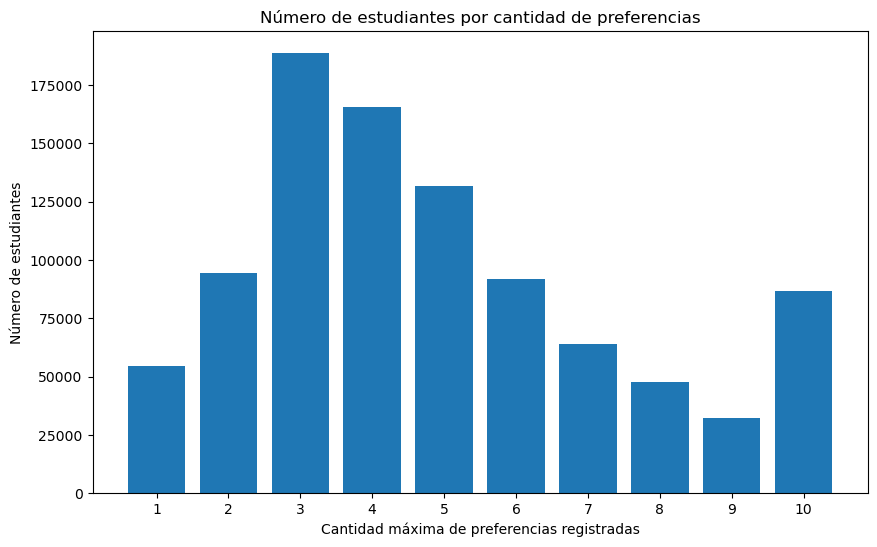

In [ ]:
import matplotlib.pyplot as plt

df_postulaciones["PREFERENCIA"] = pd.to_numeric(df_postulaciones["PREFERENCIA"], errors="coerce")
prefs_por_persona = df_postulaciones.groupby("MRUNANIO")["PREFERENCIA"].max()

conteo = prefs_por_persona.value_counts().sort_index()  # cuántas personas tienen 1,2,3... preferencias

plt.figure(figsize=(10,6))
plt.bar(conteo.index.astype(int), conteo.values)
plt.title("Número de estudiantes por cantidad de preferencias")
plt.xlabel("Cantidad máxima de preferencias registradas")
plt.ylabel("Número de estudiantes")
plt.xticks(conteo.index.astype(int))
plt.show()

 Ahora debemos normalizar los datos-

Este proceso de normalizacion lo hacemos porque queremos asegurar que las preferencias estén en una escala comparable, lo que facilita el análisis posterior. Sino, si dejamos los IDs sin normalizar, podrían tener un rango muy amplio dependiendo de cuántas carreras únicas haya, lo que podría afectar negativamente a algunos algoritmos de clustering o análisis que sean sensibles a la escala de las variables. Al normalizar, garantizamos que cada preferencia tenga un impacto proporcional en el análisis, e independientemente del número total de carreras.

In [13]:
# ====== Parámetro de control ======
max_prefs = 3  # cambiar a 10 o el número que quieras incluir

# ====== Paso 1: Asegurar tipos ======
df_postulaciones['PREFERENCIA'] = pd.to_numeric(df_postulaciones['PREFERENCIA'], errors='coerce') # Convertir a numérico, forzando errores a NaN

# ====== Paso 2: Filtrar solo las preferencias deseadas ======
df_filtrado = df_postulaciones[df_postulaciones['PREFERENCIA'].between(1, max_prefs)] # Filtrar solo las filas donde PREFERENCIA esté entre 1 y max_prefs

# ====== Paso 3: Pivotear ======
df_wide = df_filtrado.pivot_table( # Pivotear la tabla para tener una columna por cada preferencia
    index='MRUNANIO',
    columns='PREFERENCIA',
    values='Generic_Career',
    aggfunc='first'
)

# ====== Paso 4: Renombrar columnas ======
df_wide.columns = [f'Preferencia_{int(col)}' for col in df_wide.columns] # Renombrar columnas a Preferencia_1, Preferencia_2, etc.
df_wide = df_wide.reset_index()

# ====== Paso 5: Crear diccionario único de carreras ======
carreras_unicas = pd.Series(df_wide.drop(columns='MRUNANIO').values.ravel()).dropna().unique() # Obtener todas las carreras únicas (sin NaN)
mapa_carreras = {nombre: i for i, nombre in enumerate(sorted(carreras_unicas))} # Crear un diccionario que mapea cada carrera a un ID numérico

# ====== Paso 6: Codificación y normalización por preferencia ======
for col in [f'Preferencia_{i}' for i in range(1, max_prefs + 1)]: # Iterar sobre cada columna de preferencia
    if col in df_wide.columns: # Verificar que la columna exista (en caso de que max_prefs sea mayor que el número real de preferencias)
        df_wide[f'{col}_ID'] = df_wide[col].map(mapa_carreras) # Mapear cada carrera a su ID numérico
        df_wide[f'{col}_ID_Norm'] = df_wide[f'{col}_ID'] / len(mapa_carreras) # Normalizar dividiendo por el número total de carreras únicas

# ====== Resultado final ======
df_wide.head()


,MRUNANIO,Preferencia_1,Preferencia_2,Preferencia_3,Preferencia_1_ID,Preferencia_1_ID_Norm,Preferencia_2_ID,Preferencia_2_ID_Norm,Preferencia_3_ID,Preferencia_3_ID_Norm
0,10000020-2012,Nutricion y Dietetica,NaN,NaN,104.0,0.608187,NaN,NaN,NaN,NaN
1,10000026-2016,Pedagogia en Matematicas y Computacion,NaN,NaN,128.0,0.748538,NaN,NaN,NaN,NaN
2,10000097-2013,Medicina,Medicina,Medicina,101.0,0.590643,101.0,0.590643,101.0,0.590643
3,10000109-2017,"Ingenieria Civil, Plan Comun y Licenciatura en...",Arquitectura,Ingenieria Civil en Minas,61.0,0.356725,10.0,0.058480,57.0,0.333333
4,10000196-2014,Geologia,Ingenieria Civil en Minas,Ingenieria en Geomensura y Cartografia,38.0,0.222222,57.0,0.333333,78.0,0.456140
